# Parcel Invoice Cost Normalization

**Objective:** Build a shipment-level normalized cost model that allows fair carrier comparison by separating core transportation cost from surcharges, penalties, and non-comparable exception charges.

**Deliverable structure:**
1. Data Overview
2. Cleaning Steps
3. Cost Model Design
4. Aggregation Logic
5. Analysis (Carrier Comparison)
6. Worst 10% Analysis
7. Visualizations
8. Final Insights & Recommendations

## Submission Details

**Assignment link:** https://docs.google.com/document/d/1fEbKgPYLBvdyedP_o9vJcK1OR7efNviAZ4gjqCv2bLY/edit?tab=t.0

**How to run this notebook:**
1. Open this notebook in Google Colab.
2. Run cells from top to bottom.
3. Upload `invoice_data.xlsx` when prompted.
4. The notebook will generate cleaned outputs, carrier summaries, worst-10% analysis, and charts.
5. Download any generated CSVs if needed for supporting material.

**AI usage disclosure:**
AI tools were used to assist with structuring the analysis, drafting Python code, refining charge classification logic, and improving notebook documentation/comments. All analysis logic, assumptions, business rules, and final outputs were reviewed and validated on the provided dataset before submission.

## 0. Setup

Run this cell first. Then upload the invoice file when prompted.

In [1]:
!pip -q install pandas openpyxl matplotlib seaborn tabulate

In [2]:
from google.colab import files
import json
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

uploaded = files.upload()
if not uploaded:
    raise ValueError('Please upload invoice_data.xlsx to continue.')

uploaded_name = next(iter(uploaded))
INPUT_FILE = Path('/content') / uploaded_name
OUTPUT_DIR = Path('/content/outputs')
CHART_DIR = OUTPUT_DIR / 'charts'
OUTPUT_DIR.mkdir(exist_ok=True)
CHART_DIR.mkdir(exist_ok=True)

pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 200)
sns.set_theme(style='whitegrid')

print(f'Loaded file: {INPUT_FILE}')

Saving invoice_data.xlsx to invoice_data.xlsx
Loaded file: /content/invoice_data.xlsx


## 1. Data Overview

The first step is to inspect the schema, data types, shipment identifiers, carrier mix, and charge-type universe.

In [3]:
raw_df = pd.read_excel(INPUT_FILE)
raw_df.head()

,Tracking Number,Carrier Name,Service Level,Zones,Weight (lbs),Dimensions (in),Charge Type,Charge,Pickup Zipcode,Dropoff Zipcode,Date of Delivery
0,1F1234567890123458,Delhivery,Ground,Zone 6,11,12x12x8,Adult Signature Required,11.25,10005,90001,2024-04-22
1,1F1234567890123451,DTDC,Ground,Zone 4,5,12x12x8,Additional Tax,5.50,60606,90210,2023-08-14
2,1F1234567890123456,Blue Dart,2Day,Zone 3,12,12x12x8,Adjustment,7.50,60601,90210,2024-01-06
3,1F1234567890123459,Delhivery,Ground,Zone 6,11,12x12x8,Adult Signature Required,11.25,10005,90001,2024-04-22
4,1F1234567890123454,FedEx,Next Day Air,Zone 1,7,12x12x8,Addl. Handling Weight,9.00,10005,90002,2023-11-26


In [4]:
overview = pd.DataFrame({
    'column': raw_df.columns,
    'dtype': raw_df.dtypes.astype(str).values,
    'null_count': raw_df.isna().sum().values,
    'non_null_count': raw_df.notna().sum().values,
    'nunique': [raw_df[col].nunique(dropna=True) for col in raw_df.columns]
})
overview

,column,dtype,null_count,non_null_count,nunique
0,Tracking Number,object,0,214,106
1,Carrier Name,object,0,214,9
2,Service Level,object,0,214,8
3,Zones,object,0,214,11
4,Weight (lbs),object,0,214,14
5,Dimensions (in),object,0,214,9
6,Charge Type,object,0,214,196
7,Charge,float64,0,214,27
8,Pickup Zipcode,int64,0,214,27
9,Dropoff Zipcode,int64,0,214,30


In [5]:
print('Rows:', len(raw_df))
print('Unique shipments (Tracking Number):', raw_df['Tracking Number'].nunique())
print('Unique carriers:', raw_df['Carrier Name'].nunique())
print('Unique charge types:', raw_df['Charge Type'].nunique())
print('Exact duplicate rows:', raw_df.duplicated().sum())
print('Potential duplicate invoice lines:', raw_df.duplicated(subset=['Tracking Number', 'Charge Type', 'Charge']).sum())

Rows: 214
Unique shipments (Tracking Number): 106
Unique carriers: 9
Unique charge types: 196
Exact duplicate rows: 0
Potential duplicate invoice lines: 0


In [6]:
raw_df['Charge Type'].value_counts().head(25).to_frame('row_count')

,row_count
Charge Type,
Additional Tax,5
Adjustment,5
Adult Signature Required,3
Address Correction,3
Additional weight charge,3
Additional Vat Charge,3
Admin. Fees,2
Fuel Surcharge,2
Addl. Handling Weight,1


**Initial data reading:** `Tracking Number` is the most reliable shipment identifier because it repeats across line items. The charge taxonomy is very fragmented, so standardization is necessary before fair cost comparison.

## 2. Cleaning Steps

This section standardizes charge names, converts mixed formats, and prepares the file for shipment-level aggregation.

In [7]:
def slugify(value: str) -> str:
    value = re.sub(r'[^a-z0-9]+', '_', value.lower()).strip('_')
    return value or 'unknown'


def canonicalize_charge_type(charge_type: str) -> str:
    text = str(charge_type).strip().lower()
    text = re.sub(r'\baddl\b', 'additional', text)
    text = re.sub(r'\bahs\b', 'additional handling surcharge', text)
    text = re.sub(r'\bfsc\b', 'fuel surcharge', text)
    text = re.sub(r'\bresi\b', 'residential', text)
    text = re.sub(r'\bcomm\b', 'commercial', text)
    text = re.sub(r'\bp\/u\b', 'pickup', text)
    text = re.sub(r'w\/e\s*', '', text)
    text = re.sub(r'[^a-z0-9]+', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()

    replacements = {
        'base rate': 'base freight',
        'freight': 'base freight',
        'fuel surcharge adjustment': 'fuel surcharge',
        'additional weight charge': 'additional weight charge',
        'additional handling weight': 'additional handling weight',
        'adult signature required': 'signature required',
        'adult signature': 'signature required',
        'direct signature': 'signature required',
        'delivery confirmation signature': 'signature required',
        'delivery confirmation signature commercial': 'signature required',
        'declared value charge': 'declared value',
        'delivery area surcharge adjustment': 'delivery area surcharge',
        'delivery area surcharge extended adjustment': 'delivery area surcharge extended',
        'das resi': 'delivery area surcharge residential',
        'das comm': 'delivery area surcharge commercial',
        'das remote resi': 'remote area surcharge residential',
        'das remote comm': 'remote area surcharge commercial',
        'das extended resi': 'extended area surcharge residential',
        'das extended comm': 'extended area surcharge commercial',
        'admin fees': 'administrative fee'
    }
    return replacements.get(text, text)


def classify_charge(canonical_charge: str):
    text = canonical_charge
    base_keywords = ['base freight', 'line haul', 'linehaul', 'shipping charge', 'transportation charge', 'freight charge']
    essential_keywords = [
        'fuel surcharge', 'delivery area surcharge', 'extended area surcharge', 'remote area surcharge',
        'residential', 'signature', 'declared value', 'cod', 'cash on delivery', 'additional handling',
        'additional weight', 'overweight', 'oversize', 'large package', 'limited access',
        'weekend delivery', 'saturday delivery', 'sunday delivery', 'remote area', 'out of area',
        'special handling', 'hazardous', 'tax', 'vat'
    ]
    avoidable_keywords = [
        'adjustment', 'address correction', 'zip code correction', 'correction', 'administrative fee',
        'alternate broker', 'billing adjustment', 'late arrival', 'third attempt', 'any third attempt',
        'reversal penalty', 'penalty', 'future day pickup', 'pickup', 'broker', 'customs', 'duty',
        'warehouse', 'clearance', 'entry', 'disbursement', 'gst', 'pst', 'hst'
    ]
    pure_tax_keywords = {'tax', 'vat'}

    if any(keyword in text for keyword in base_keywords):
        return 'base_cost', 'include'

    if any(keyword in text for keyword in avoidable_keywords):
        if text in pure_tax_keywords:
            return 'essential_surcharge', 'include'
        return 'penalty_or_non_comparable', 'exclude'

    if any(keyword in text for keyword in essential_keywords):
        return 'essential_surcharge', 'include'

    return 'unclear_review', 'exclude'


def build_charge_lookup(df: pd.DataFrame) -> pd.DataFrame:
    lookup = pd.DataFrame({'raw_charge_type': sorted(df['Charge Type'].dropna().unique())})
    lookup['canonical_charge_type'] = lookup['raw_charge_type'].map(canonicalize_charge_type)
    classified = lookup['canonical_charge_type'].map(classify_charge)
    lookup['charge_bucket'] = classified.map(lambda x: x[0])
    lookup['include_in_normalized_cost'] = classified.map(lambda x: x[1] == 'include')
    return lookup


def compute_normalized_cost(df: pd.DataFrame) -> pd.DataFrame:
    working = df.copy()
    working['canonical_charge_type'] = working['Charge Type'].map(canonicalize_charge_type)
    classified = working['canonical_charge_type'].map(classify_charge)
    working['charge_bucket'] = classified.map(lambda x: x[0])
    working['include_in_normalized_cost'] = classified.map(lambda x: x[1] == 'include')
    working['included_charge_amount'] = np.where(working['include_in_normalized_cost'], working['Charge'], 0.0)
    return working


In [8]:
charge_lookup = build_charge_lookup(raw_df)
charge_lookup.head(30)

,raw_charge_type,canonical_charge_type,charge_bucket,include_in_normalized_cost
0,AHS - Weight,additional handling surcharge weight,essential_surcharge,True
1,Additional Tax,additional tax,essential_surcharge,True
2,Additional Vat Charge,additional vat charge,essential_surcharge,True
3,Additional Weight Charge,additional weight charge,essential_surcharge,True
4,Additional weight charge,additional weight charge,essential_surcharge,True
5,Addl. Handling Weight,additional handling weight,essential_surcharge,True
6,Addl. Handling weight,additional handling weight,essential_surcharge,True
7,Address Correction,address correction,penalty_or_non_comparable,False
8,Adjustment,adjustment,penalty_or_non_comparable,False
9,Admin. Fees,administrative fee,penalty_or_non_comparable,False


In [9]:
cleaned = compute_normalized_cost(raw_df)
cleaned.columns = [slugify(col) for col in cleaned.columns]
cleaned['weight_lbs'] = cleaned['weight_lbs'].astype(str).str.extract(r'([0-9]+(?:\.[0-9]+)?)', expand=False).astype(float)
cleaned['zones'] = cleaned['zones'].astype(str).str.strip()
cleaned['carrier_name'] = cleaned['carrier_name'].astype(str).str.strip()
cleaned['service_level'] = cleaned['service_level'].astype(str).str.strip()
cleaned['charge_type'] = cleaned['charge_type'].astype(str).str.strip()
cleaned['included_cost'] = np.where(cleaned['include_in_normalized_cost'], cleaned['charge'], 0.0)
cleaned['excluded_cost'] = np.where(cleaned['include_in_normalized_cost'], 0.0, cleaned['charge'])
cleaned.head()

,tracking_number,carrier_name,service_level,zones,weight_lbs,dimensions_in,charge_type,charge,pickup_zipcode,dropoff_zipcode,date_of_delivery,canonical_charge_type,charge_bucket,include_in_normalized_cost,included_charge_amount,included_cost,excluded_cost
0,1F1234567890123458,Delhivery,Ground,Zone 6,11.0,12x12x8,Adult Signature Required,11.25,10005,90001,2024-04-22,signature required,essential_surcharge,True,11.25,11.25,0.0
1,1F1234567890123451,DTDC,Ground,Zone 4,5.0,12x12x8,Additional Tax,5.50,60606,90210,2023-08-14,additional tax,essential_surcharge,True,5.50,5.50,0.0
2,1F1234567890123456,Blue Dart,2Day,Zone 3,12.0,12x12x8,Adjustment,7.50,60601,90210,2024-01-06,adjustment,penalty_or_non_comparable,False,0.00,0.00,7.5
3,1F1234567890123459,Delhivery,Ground,Zone 6,11.0,12x12x8,Adult Signature Required,11.25,10005,90001,2024-04-22,signature required,essential_surcharge,True,11.25,11.25,0.0
4,1F1234567890123454,FedEx,Next Day Air,Zone 1,7.0,12x12x8,Addl. Handling Weight,9.00,10005,90002,2023-11-26,additional handling weight,essential_surcharge,True,9.00,9.00,0.0


In [10]:
classification_summary = charge_lookup['charge_bucket'].value_counts().rename_axis('charge_bucket').reset_index(name='count')
classification_summary

,charge_bucket,count
0,penalty_or_non_comparable,160
1,essential_surcharge,27
2,unclear_review,7
3,base_cost,2


**Cleaning conclusion:** The main issue is not missing data; it is fragmented charge labels and mixed business meaning across charge types. A rule-based mapping is therefore the right approach.

## 3. Cost Model Design

### Normalized cost definition

`normalized_cost = base_cost + essential_surcharges`

### Included
- Base freight / transportation
- Essential shipment-linked surcharges such as fuel, delivery-area, residential, signature, additional handling, additional weight, and simple tax/VAT rows

### Excluded
- Avoidable penalties and operational leakage: corrections, admin fees, billing adjustments
- Non-comparable import/export charges: customs, duty, brokerage, warehouse, clearance
- Pickup-event and special exception charges that distort core carrier comparison
- Ambiguous rows are excluded conservatively and flagged for review

In [11]:
charge_lookup.sort_values(['charge_bucket', 'canonical_charge_type']).head(50)

,raw_charge_type,canonical_charge_type,charge_bucket,include_in_normalized_cost
15,Base Rate,base freight,base_cost,True
85,Freight,base freight,base_cost,True
0,AHS - Weight,additional handling surcharge weight,essential_surcharge,True
5,Addl. Handling Weight,additional handling weight,essential_surcharge,True
6,Addl. Handling weight,additional handling weight,essential_surcharge,True
1,Additional Tax,additional tax,essential_surcharge,True
2,Additional Vat Charge,additional vat charge,essential_surcharge,True
3,Additional Weight Charge,additional weight charge,essential_surcharge,True
4,Additional weight charge,additional weight charge,essential_surcharge,True
55,DAS Extended Resi,das extended residential,essential_surcharge,True


## 4. Aggregation Logic

All invoice rows are aggregated to one shipment-level record using `Tracking Number` as the shipment key.

In [12]:
shipment_level = (
    cleaned.groupby('tracking_number')
    .agg(
        carrier_name=('carrier_name', 'first'),
        service_level=('service_level', 'first'),
        zones=('zones', 'first'),
        weight_lbs=('weight_lbs', 'first'),
        total_invoice_cost=('charge', 'sum'),
        normalized_cost=('included_cost', 'sum'),
        excluded_cost=('excluded_cost', 'sum'),
        line_count=('charge_type', 'count')
    )
    .reset_index()
)

included_labels = (
    cleaned[cleaned['include_in_normalized_cost']]
    .groupby('tracking_number')['canonical_charge_type']
    .apply(lambda s: ', '.join(sorted(pd.unique(s))[:5]))
    .rename('top_included_charge_types')
)
excluded_labels = (
    cleaned[~cleaned['include_in_normalized_cost']]
    .groupby('tracking_number')['canonical_charge_type']
    .apply(lambda s: ', '.join(sorted(pd.unique(s))[:5]))
    .rename('top_excluded_charge_types')
)

shipment_level = shipment_level.merge(included_labels, on='tracking_number', how='left')
shipment_level = shipment_level.merge(excluded_labels, on='tracking_number', how='left')
shipment_level['top_included_charge_types'] = shipment_level['top_included_charge_types'].fillna('None')
shipment_level['top_excluded_charge_types'] = shipment_level['top_excluded_charge_types'].fillna('None')
shipment_level['cost_reduction'] = shipment_level['total_invoice_cost'] - shipment_level['normalized_cost']
shipment_level['pct_reduction'] = np.where(
    shipment_level['total_invoice_cost'] > 0,
    shipment_level['cost_reduction'] / shipment_level['total_invoice_cost'],
    0.0
)
shipment_level.head()

,tracking_number,carrier_name,service_level,zones,weight_lbs,total_invoice_cost,normalized_cost,excluded_cost,line_count,top_included_charge_types,top_excluded_charge_types,cost_reduction,pct_reduction
0,0F10987POIUY,Safe Express,Economy,2,4.0,25.0,0.0,25.0,1,None,billing adjustment for 06 03 2023,25.0,1.0
1,0F10987ZXCVB,Ecom Express,Ground,2,4.0,100.0,0.0,100.0,4,None,"early surcharge, future day pickup additional ...",100.0,1.0
2,0F32109MNBVC,Delhivery,Standard,4,5.0,30.0,0.0,30.0,1,None,cst additional duty,30.0,1.0
3,0F32109POIUY,Ekart Logistics,Priority,3,4.0,25.0,0.0,25.0,1,None,delivery confirmation signature commercial adj...,25.0,1.0
4,0F32109ZXCVB,DTDC,Express,1,5.0,30.0,30.0,0.0,1,das remote residential,None,0.0,0.0


In [13]:
shipment_level[['total_invoice_cost', 'normalized_cost', 'excluded_cost']].describe().round(2)

,total_invoice_cost,normalized_cost,excluded_cost
count,106.00,106.00,106.00
mean,49.03,7.99,41.04
std,40.02,12.06,40.47
min,5.50,0.00,0.00
25%,25.00,0.00,7.56
50%,27.25,0.00,25.00
75%,100.00,11.88,78.75
max,135.00,50.00,135.00


## 5. Analysis: Carrier Comparison

This compares carrier performance before and after normalization.

In [14]:
carrier_summary = (
    shipment_level.groupby('carrier_name')
    .agg(
        shipment_count=('tracking_number', 'count'),
        avg_total_cost=('total_invoice_cost', 'mean'),
        avg_normalized_cost=('normalized_cost', 'mean'),
        total_invoice_spend=('total_invoice_cost', 'sum'),
        total_normalized_spend=('normalized_cost', 'sum'),
        avg_cost_reduction=('cost_reduction', 'mean')
    )
    .reset_index()
)
carrier_summary['pct_change_vs_total'] = np.where(
    carrier_summary['avg_total_cost'] > 0,
    (carrier_summary['avg_normalized_cost'] - carrier_summary['avg_total_cost']) / carrier_summary['avg_total_cost'] * 100,
    0.0
)
carrier_summary.sort_values('avg_normalized_cost').round(2)

,carrier_name,shipment_count,avg_total_cost,avg_normalized_cost,total_invoice_spend,total_normalized_spend,avg_cost_reduction,pct_change_vs_total
7,Gati,12,50.15,2.08,601.75,25.00,48.06,-95.85
0,Blue Dart,11,46.70,3.25,513.75,35.75,43.45,-93.04
1,DHL,11,51.05,5.64,561.50,62.00,45.41,-88.96
3,Delhivery,13,42.37,7.12,550.75,92.50,35.25,-83.20
6,FedEx,12,61.98,9.67,743.75,116.00,52.31,-84.40
5,Ekart Logistics,13,41.02,9.69,533.25,126.00,31.33,-76.37
4,Ecom Express,11,48.43,11.11,532.75,122.25,37.32,-77.05
2,DTDC,14,42.20,11.30,590.75,158.25,30.89,-73.21
8,Safe Express,9,63.25,12.14,569.25,109.25,51.11,-80.81


In [15]:
total_invoice_spend = shipment_level['total_invoice_cost'].sum()
total_normalized_spend = shipment_level['normalized_cost'].sum()
spend_removed = total_invoice_spend - total_normalized_spend

print('Total invoice spend:', round(total_invoice_spend, 2))
print('Total normalized spend:', round(total_normalized_spend, 2))
print('Spend removed by normalization:', round(spend_removed, 2))
print('Share removed:', round(spend_removed / total_invoice_spend * 100, 2), '%')

best_carrier = carrier_summary.sort_values('avg_normalized_cost').iloc[0]
worst_carrier = carrier_summary.sort_values('avg_normalized_cost', ascending=False).iloc[0]
print('\nCheapest after normalization:', best_carrier['carrier_name'], '| avg normalized cost =', round(best_carrier['avg_normalized_cost'], 2))
print('Most expensive after normalization:', worst_carrier['carrier_name'], '| avg normalized cost =', round(worst_carrier['avg_normalized_cost'], 2))

Total invoice spend: 5197.5
Total normalized spend: 847.0
Spend removed by normalization: 4350.5
Share removed: 83.7 %

Cheapest after normalization: Gati | avg normalized cost = 2.08
Most expensive after normalization: Safe Express | avg normalized cost = 12.14


In [16]:
charge_spend = (
    cleaned.groupby(['canonical_charge_type', 'charge_bucket'], as_index=False)
    .agg(
        total_spend=('charge', 'sum'),
        included_spend=('included_cost', 'sum'),
        excluded_spend=('excluded_cost', 'sum'),
        rows=('tracking_number', 'count')
    )
)
charge_spend.sort_values('excluded_spend', ascending=False).head(15)

,canonical_charge_type,charge_bucket,total_spend,included_spend,excluded_spend,rows
6,adjustment,penalty_or_non_comparable,67.0,0.0,67.0,5
7,administrative fee,penalty_or_non_comparable,39.5,0.0,39.5,2
5,address correction,penalty_or_non_comparable,39.5,0.0,39.5,3
19,billing adjustment for 02 25 2023,penalty_or_non_comparable,30.0,0.0,30.0,1
10,australia gst,penalty_or_non_comparable,30.0,0.0,30.0,1
24,billing adjustment for 04 01 2023,penalty_or_non_comparable,30.0,0.0,30.0,1
38,brokerage gst,penalty_or_non_comparable,30.0,0.0,30.0,1
32,billing adjustment for 05 27 2023,penalty_or_non_comparable,30.0,0.0,30.0,1
26,billing adjustment for 04 15 2023,penalty_or_non_comparable,30.0,0.0,30.0,1
43,cst additional duty,penalty_or_non_comparable,30.0,0.0,30.0,1


**Interpretation:** Carrier rankings change materially after normalization because many invoice rows are operational exceptions or non-comparable admin/import charges rather than core transport economics.

## 6. Worst 10% Analysis

This isolates the top decile of shipments by normalized cost and diagnoses their concentration by carrier, zone, and charge driver.

In [17]:
worst_threshold = shipment_level['normalized_cost'].quantile(0.90)
worst_shipments = shipment_level[shipment_level['normalized_cost'] >= worst_threshold].copy()
worst_shipments = worst_shipments.sort_values('normalized_cost', ascending=False)

print('Worst 10% threshold:', round(worst_threshold, 2))
print('Worst-segment shipment count:', len(worst_shipments))
print('Worst-segment share of normalized spend:', round(worst_shipments['normalized_cost'].sum() / shipment_level['normalized_cost'].sum() * 100, 2), '%')

Worst 10% threshold: 25.5
Worst-segment shipment count: 11
Worst-segment share of normalized spend: 41.06 %


In [18]:
worst_by_carrier = worst_shipments.groupby('carrier_name')['tracking_number'].count().sort_values(ascending=False).to_frame('shipment_count')
worst_by_zone = worst_shipments.groupby('zones')['tracking_number'].count().sort_values(ascending=False).to_frame('shipment_count')

display(worst_by_carrier)
display(worst_by_zone)
worst_shipments[['tracking_number', 'carrier_name', 'zones', 'normalized_cost', 'total_invoice_cost', 'excluded_cost', 'top_included_charge_types', 'top_excluded_charge_types']].head(12)

,shipment_count
carrier_name,
Safe Express,3
DTDC,2
FedEx,2
Ekart Logistics,2
Delhivery,1
Ecom Express,1


,shipment_count
zones,
2,4
1,2
4,2
5,2
3,1


,tracking_number,carrier_name,zones,normalized_cost,total_invoice_cost,excluded_cost,top_included_charge_types,top_excluded_charge_types
95,8F98765MNBVC,Safe Express,2,50.00,50.00,0.0,"das extended residential, signature required",None
57,4F10987NBVCX,Delhivery,3,35.00,35.00,0.0,signature required,None
86,7F65432MNOPQ,Ecom Express,1,32.00,32.00,0.0,additional weight charge,None
76,6F43210MNBVC,Safe Express,2,30.00,130.00,100.0,signature required,future day pickup additional handling oversize...
8,0F76543LKJHG,FedEx,5,30.00,105.00,75.0,fuel surcharge,future day pickup additional handling remote a...
4,0F32109ZXCVB,DTDC,1,30.00,30.00,0.0,das remote residential,None
53,3F6789BCDEFG,DTDC,2,30.00,30.00,0.0,additional tax,None
50,3F43210LKJHG,Safe Express,4,29.25,54.25,25.0,signature required,customs ot
71,5F98765HIJKL,Ekart Logistics,4,28.50,28.50,0.0,additional vat charge,None
99,9F32109RSTUV,FedEx,5,27.00,27.00,0.0,additional handling weight,None


## 7. Visualizations

The following charts support the story: before vs after carrier economics, cost-driver Pareto, and worst-shipment concentration.

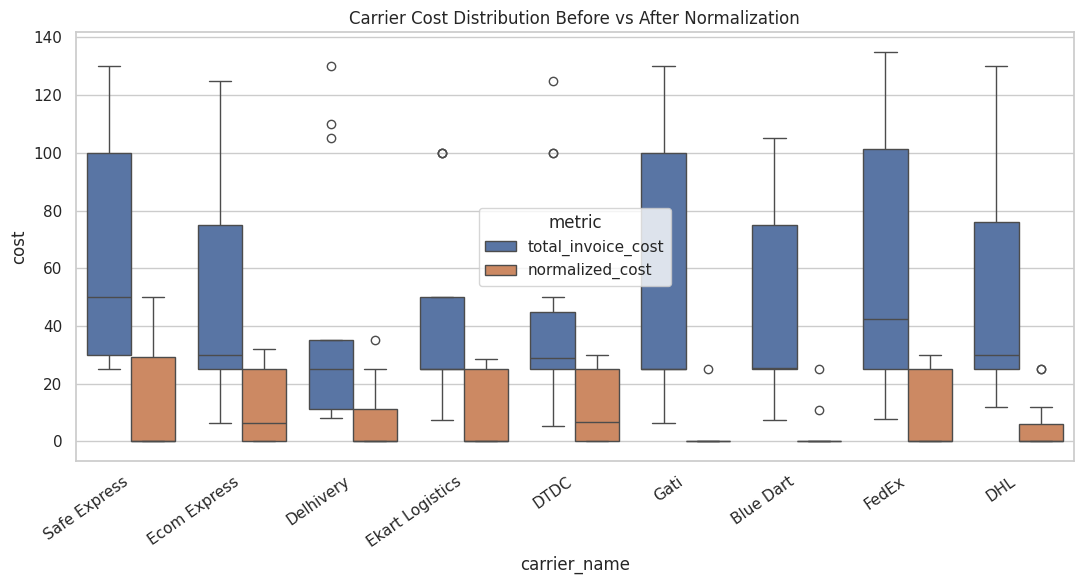

In [19]:
plot_df = shipment_level.melt(
    id_vars=['carrier_name'],
    value_vars=['total_invoice_cost', 'normalized_cost'],
    var_name='metric',
    value_name='cost'
)
plt.figure(figsize=(11, 6))
sns.boxplot(data=plot_df, x='carrier_name', y='cost', hue='metric')
plt.xticks(rotation=35, ha='right')
plt.title('Carrier Cost Distribution Before vs After Normalization')
plt.tight_layout()
plt.savefig(CHART_DIR / 'carrier_distribution_before_after.png', dpi=200)
plt.show()

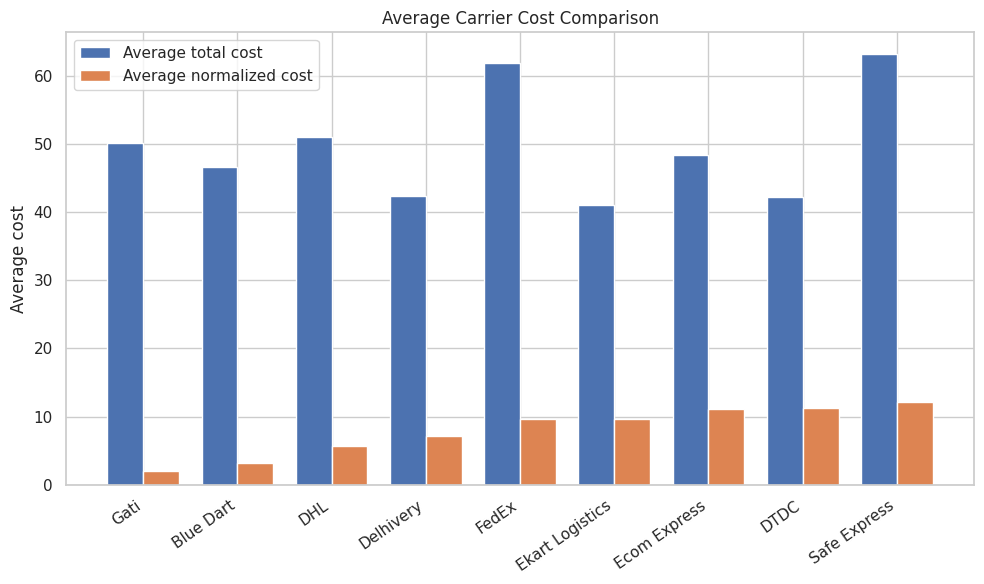

In [20]:
compare_df = carrier_summary.sort_values('avg_normalized_cost')
x = np.arange(len(compare_df))
width = 0.38

plt.figure(figsize=(10, 6))
plt.bar(x - width / 2, compare_df['avg_total_cost'], width=width, label='Average total cost')
plt.bar(x + width / 2, compare_df['avg_normalized_cost'], width=width, label='Average normalized cost')
plt.xticks(x, compare_df['carrier_name'], rotation=35, ha='right')
plt.ylabel('Average cost')
plt.title('Average Carrier Cost Comparison')
plt.legend()
plt.tight_layout()
plt.savefig(CHART_DIR / 'carrier_average_cost_comparison.png', dpi=200)
plt.show()

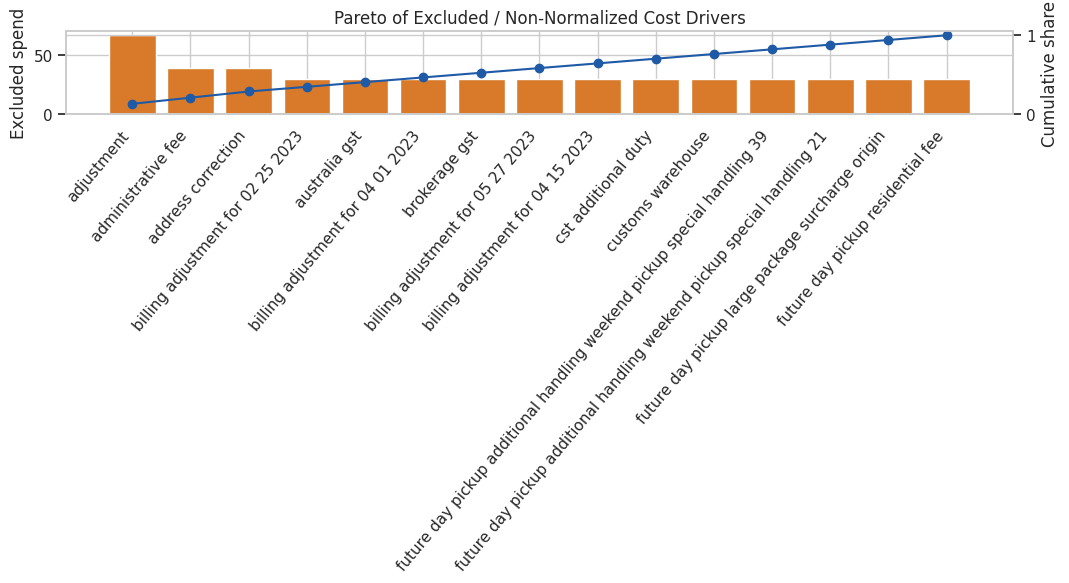

In [21]:
pareto = charge_spend.sort_values('excluded_spend', ascending=False).head(15).copy()
pareto['cum_pct'] = pareto['excluded_spend'].cumsum() / pareto['excluded_spend'].sum()

plt.figure(figsize=(11, 6))
plt.bar(pareto['canonical_charge_type'], pareto['excluded_spend'], color='#d97a2b')
plt.xticks(rotation=50, ha='right')
plt.ylabel('Excluded spend')
plt.title('Pareto of Excluded / Non-Normalized Cost Drivers')
ax2 = plt.twinx()
ax2.plot(pareto['canonical_charge_type'], pareto['cum_pct'], color='#1f5aa6', marker='o')
ax2.set_ylabel('Cumulative share')
ax2.set_ylim(0, 1.05)
plt.tight_layout()
plt.savefig(CHART_DIR / 'pareto_excluded_cost_drivers.png', dpi=200)
plt.show()

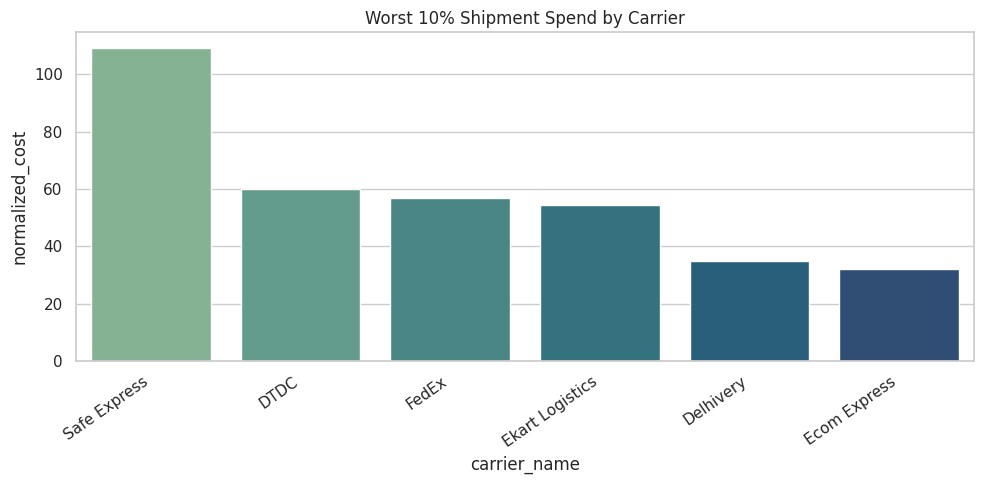

In [22]:
worst_spend_by_carrier = worst_shipments.groupby('carrier_name', as_index=False)['normalized_cost'].sum().sort_values('normalized_cost', ascending=False)
plt.figure(figsize=(10, 5))
sns.barplot(data=worst_spend_by_carrier, x='carrier_name', y='normalized_cost', hue='carrier_name', palette='crest', legend=False)
plt.xticks(rotation=35, ha='right')
plt.title('Worst 10% Shipment Spend by Carrier')
plt.tight_layout()
plt.savefig(CHART_DIR / 'worst10_carrier_breakdown.png', dpi=200)
plt.show()

## 8. Final Insights & Recommendations

### Key findings
- Carrier comparison changes substantially after removing non-comparable adjustments and exception fees.
- A large share of invoice spend is not core transportation cost and should not be used to judge carrier pricing performance.
- The worst 10% of shipments contribute a disproportionately high share of normalized spend.

### Recommendations
1. Benchmark carriers using `normalized_cost`, not raw invoice total.
2. Create a separate leakage dashboard for address corrections, admin fees, billing adjustments, and pickup/event charges.
3. Investigate worst-decile shipments first because they offer the highest savings concentration.
4. Maintain a governed charge-code master so future analyses do not depend on ad hoc text matching.
5. Tighten the upstream data contract because the dataset does not fully align with the stated assignment scope on geography and parcel profile.

### Assumptions and limitations
- `Tracking Number` is treated as the shipment key.
- Ambiguous rows are excluded conservatively.
- The file appears synthetic and does not cleanly match the narrative of 4 lb India-only shipments.
- A production-grade implementation should use an approved finance/ops charge dictionary.

In [23]:
summary = {
    'rows': int(len(raw_df)),
    'shipments': int(raw_df['Tracking Number'].nunique()),
    'carriers': int(raw_df['Carrier Name'].nunique()),
    'raw_charge_types': int(raw_df['Charge Type'].nunique()),
    'total_invoice_spend': float(shipment_level['total_invoice_cost'].sum()),
    'total_normalized_spend': float(shipment_level['normalized_cost'].sum()),
    'worst_10pct_threshold': float(worst_threshold)
}
print(json.dumps(summary, indent=2))

charge_lookup.to_csv(OUTPUT_DIR / 'charge_lookup.csv', index=False)
cleaned.to_csv(OUTPUT_DIR / 'modeled_invoice_lines.csv', index=False)
shipment_level.to_csv(OUTPUT_DIR / 'shipment_level_costs.csv', index=False)
carrier_summary.to_csv(OUTPUT_DIR / 'carrier_summary.csv', index=False)
charge_spend.to_csv(OUTPUT_DIR / 'charge_spend_summary.csv', index=False)
worst_shipments.to_csv(OUTPUT_DIR / 'worst_10pct_shipments.csv', index=False)
(OUTPUT_DIR / 'summary.json').write_text(json.dumps(summary, indent=2), encoding='utf-8')

print('\nSaved outputs to:', OUTPUT_DIR)
files.download(str(OUTPUT_DIR / 'carrier_summary.csv'))

{
  "rows": 214,
  "shipments": 106,
  "carriers": 9,
  "raw_charge_types": 196,
  "total_invoice_spend": 5197.5,
  "total_normalized_spend": 847.0,
  "worst_10pct_threshold": 25.5
}

Saved outputs to: /content/outputs


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>